In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("C:\\Users\\gagan\\Downloads\\heart_disease (1).xlsx",
                   sheet_name="Heart_disease")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [3]:
print("Shape:",df.shape)

print(df.info())

print(df.describe())

Shape: (908, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None
              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.8

In [4]:
print(df.isnull().sum())

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [5]:
df.fillna(df.mean(numeric_only=True),
          inplace=True)

In [6]:
print("Duplicates:",
      df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicates: 0


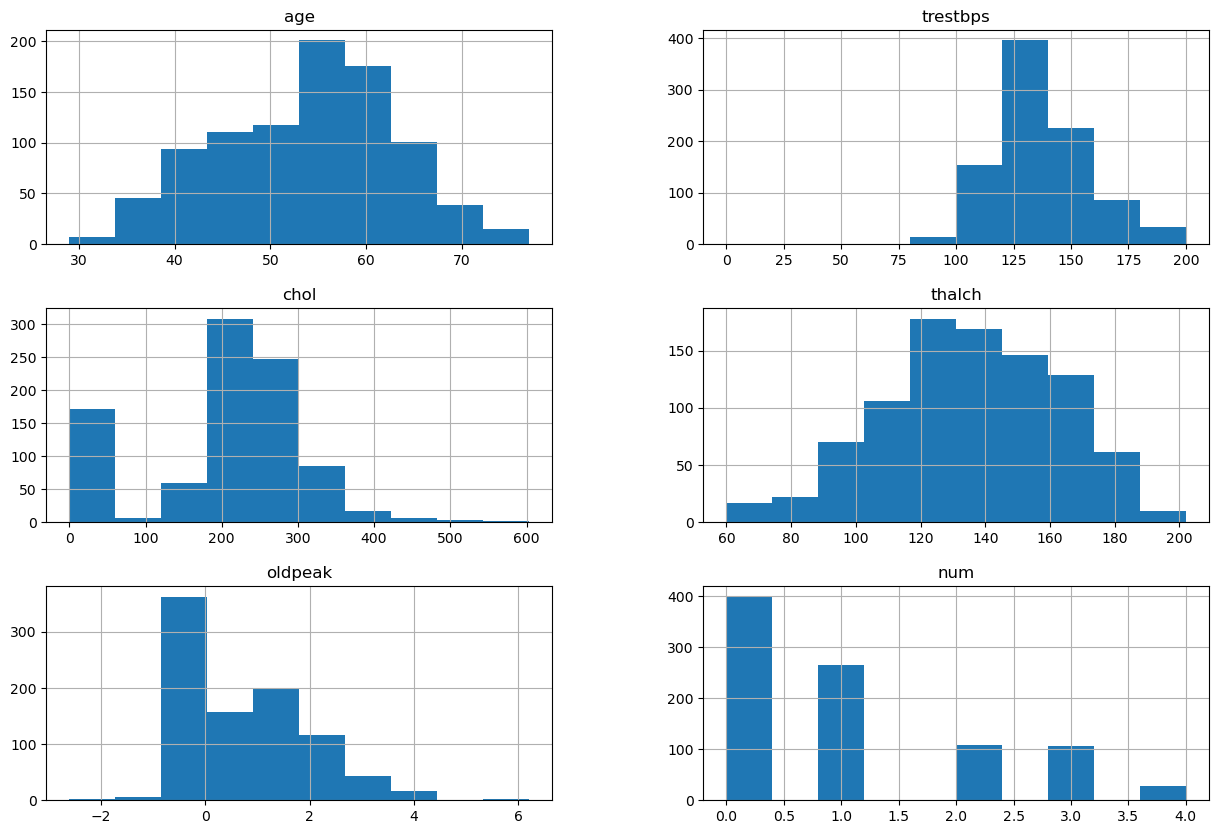

In [7]:
df.hist(figsize=(15,10))

plt.show()

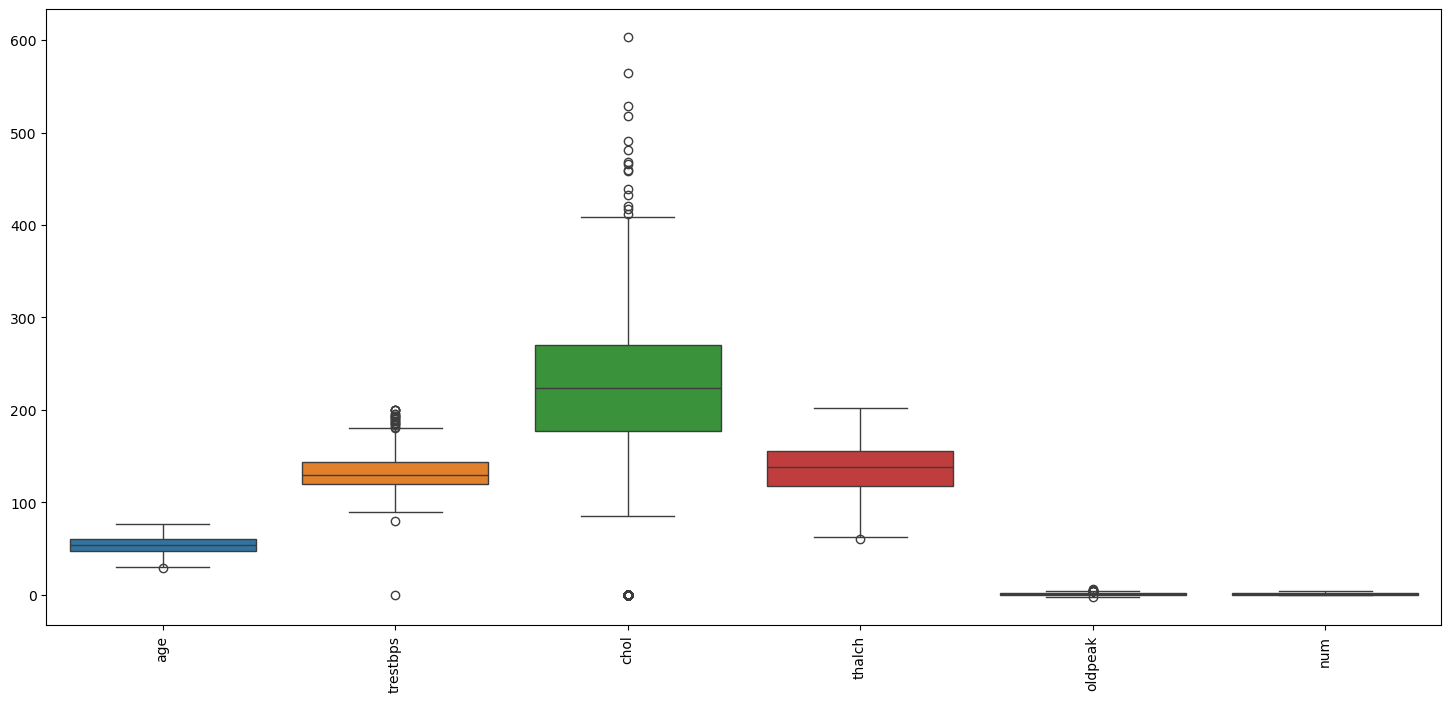

In [8]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=90)

plt.show()

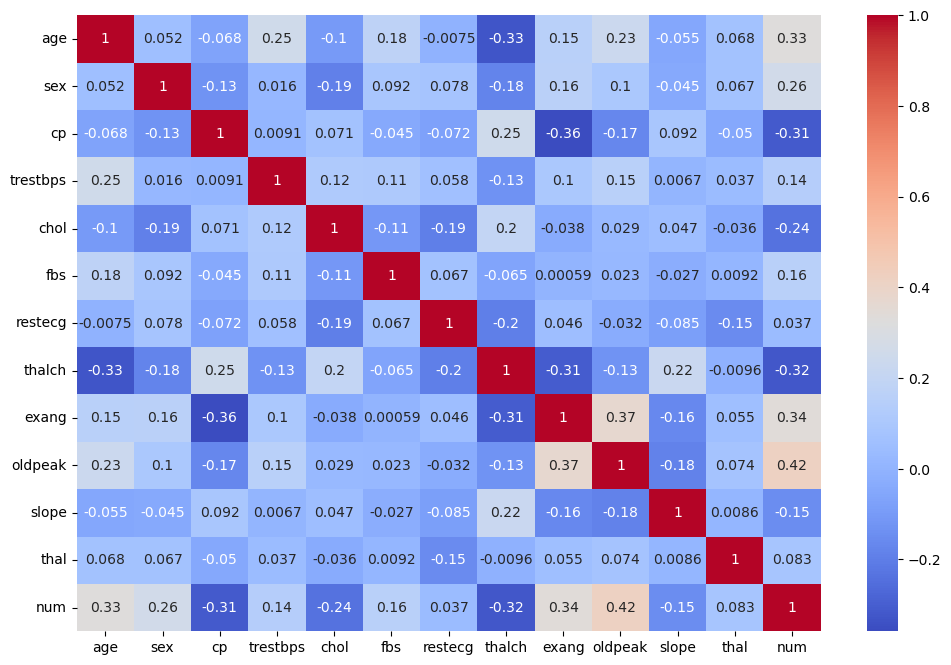

In [10]:
temp=df.copy()

for col in temp.columns:
    if temp[col].dtype=="object" or temp[col].dtype=="bool":
        temp[col]=LabelEncoder().fit_transform(
            temp[col].astype(str)
        )

plt.figure(figsize=(12,8))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:

    # convert boolean columns to string
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(str)

    # encode object columns safely
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(
            df[col].astype(str)
        )

print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalch  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0     150      1      2.3      0   
1   41    1   1       135   203    0        1     132      1      0.0      1   
2   57    1   0       140   192    0        1     148      1      0.4      1   
3   52    1   3       118   186    0        0     190      1      0.0      1   
4   57    1   0       110   201    0        1     126      3      1.5      1   

   thal  num  
0     0    0  
1     0    0  
2     0    0  
3     0    0  
4     0    0  


In [13]:
df['fbs']=df['fbs'].astype(int)
df['exang']=df['exang'].astype(int)

In [14]:
X = df.drop("num",axis=1)

y = df["num"]

print(X.shape)
print(y.shape)

(908, 12)
(908,)


In [17]:
X = df.drop("num", axis=1)

y = df["num"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print(y.value_counts())

X shape: (908, 12)
y shape: (908,)
num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)

print("Testing shape:", X_test.shape)

Training shape: (726, 12)
Testing shape: (182, 12)


In [19]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
            random_state=42
        )

model.fit(
        X_train,
        y_train
)

pred = model.predict(X_test)

print("Model trained successfully")

print(pred[:10])

Model trained successfully
[1 2 1 3 1 3 0 1 0 1]


In [20]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
        y_test,
        pred
)

print("Accuracy:", acc)

Accuracy: 0.5


In [21]:
from sklearn.metrics import classification_report

print(
classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

           0       0.76      0.71      0.74        80
           1       0.47      0.43      0.45        53
           2       0.22      0.23      0.22        22
           3       0.22      0.29      0.25        21
           4       0.00      0.00      0.00         6

    accuracy                           0.50       182
   macro avg       0.33      0.33      0.33       182
weighted avg       0.52      0.50      0.51       182



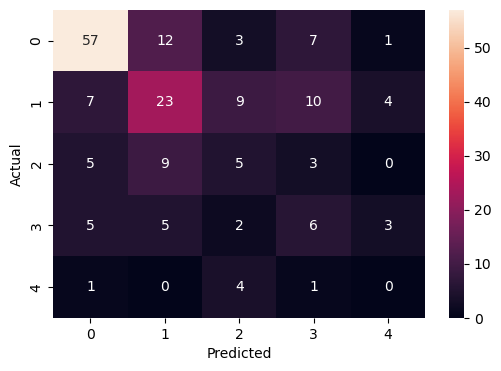

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
        y_test,
        pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {

'max_depth':[3,5,7,10],

'min_samples_split':[2,5,10],

'criterion':['gini','entropy']

}

grid = GridSearchCV(
            DecisionTreeClassifier(),
            param_grid,
            cv=5
)

grid.fit(
        X_train,
        y_train
)

print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [25]:
from sklearn.metrics import roc_auc_score

prob = model.predict_proba(X_test)

auc = roc_auc_score(
        y_test,
        prob,
        multi_class='ovr'
)

print("ROC AUC Score:", auc)


ROC AUC Score: 0.5993038973242522


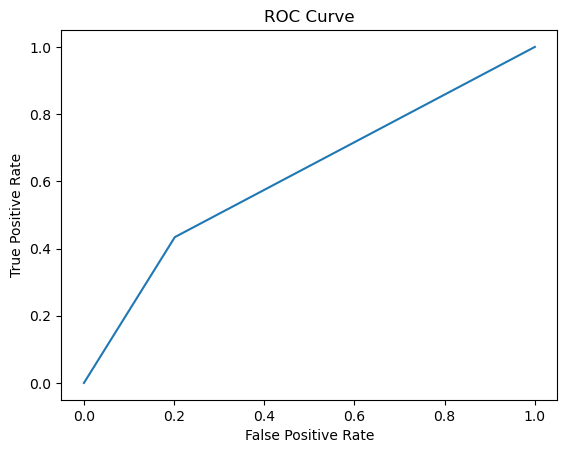

In [26]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, threshold = roc_curve(
                        y_test,
                        prob[:,1],
                        pos_label=1
                    )

plt.plot(fpr,tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

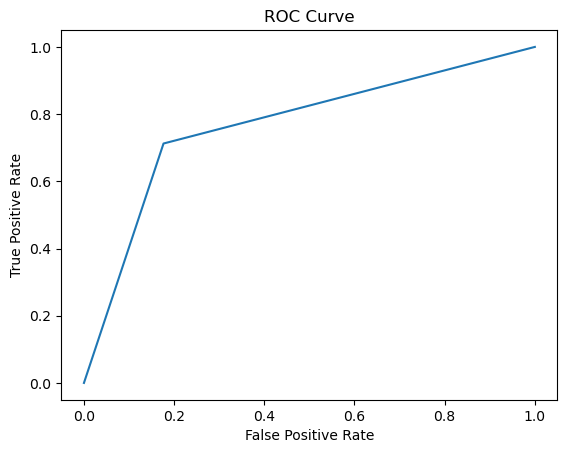

In [36]:

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

y_bin = label_binarize(y_test,
                       classes=np.unique(y))

fpr,tpr,_ = roc_curve(
                y_bin[:,0],
                prob[:,0]
            )

plt.plot(fpr,tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

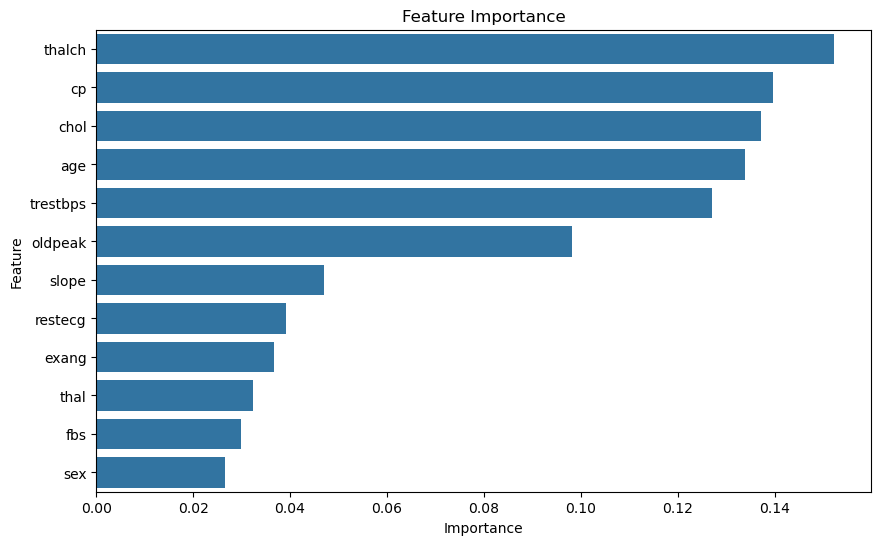

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

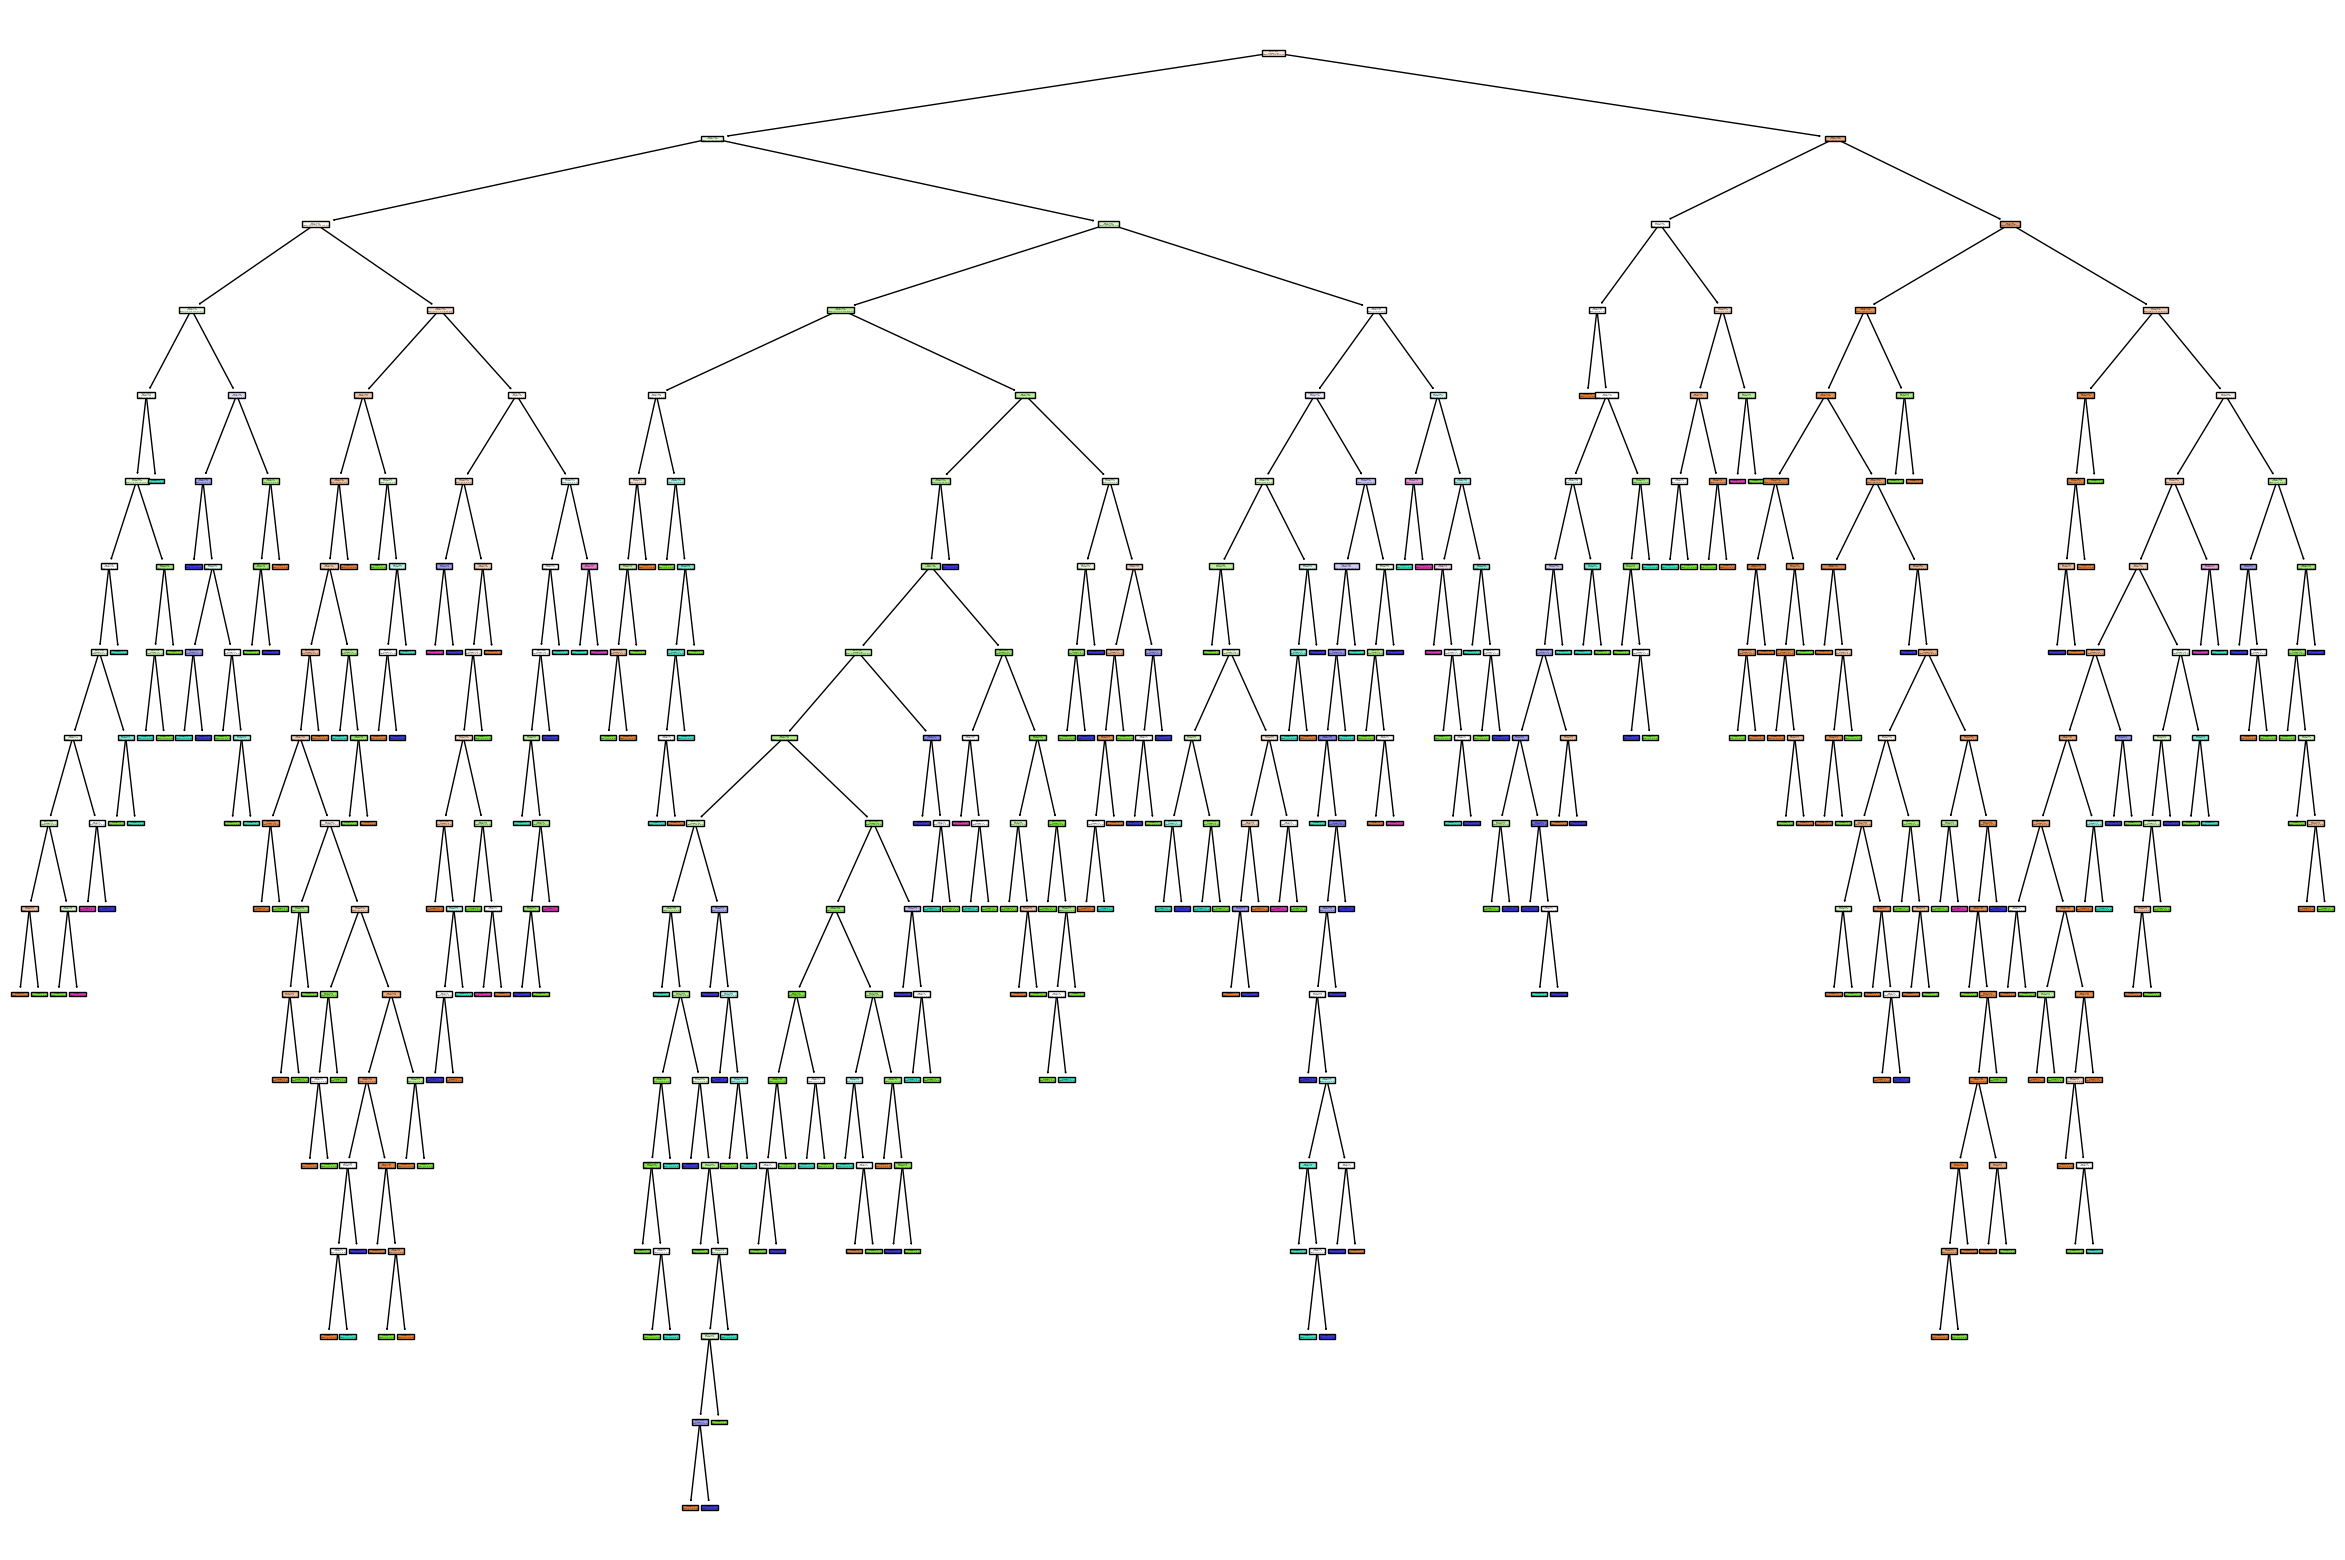

In [34]:
from sklearn import tree

plt.figure(figsize=(30,20))

tree.plot_tree(
        model,
        feature_names=X.columns,
        filled=True
)

plt.show()

In [32]:
print(df.dtypes)

print(df.nunique())

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalch        int64
exang         int64
oldpeak     float64
slope         int64
thal          int64
num           int64
dtype: object
age          49
sex           2
cp            4
trestbps     85
chol        228
fbs           2
restecg       3
thalch      122
exang         4
oldpeak      54
slope         3
thal          3
num           5
dtype: int64


In [ ]:
Q1. What are common hyperparameters of Decision Tree?

max_depth
min_samples_split
min_samples_leaf
criterion

These affect complexity and overfitting.

Q2. Difference between Label Encoding and One-Hot Encoding?

Label Encoding:

Converts categories to numbers

One Hot Encoding:

Creates separate binary columns
